In [1]:

import sys
original_sys_path = sys.path.copy()
sys.path.append('../')
from utils import *


In [2]:
max_ql = 25
max_ol = 50
system = fluxonium_oscillator_system(
    EJ = 2.65,
    EC = 0.6,
    EL = 0.13,
    Er = 7.17391479,
    g_strength = 0.13,
    qubit_level = max_ql,
    osc_level = max_ol,
    # kappa = 0.001,
    products_to_keep=[[ql, ol] for ql in [0,1,2,7] for ol in range(max_ol) ],
    computaional_states = '1,2',
    )
# t_stop = 400
tot_time =2000
tlist = np.linspace(0, tot_time, tot_time)

# results = system.run_mesolve_on_driving_osc(
#     initial_states = [system.truncate_function(qutip.basis(system.hilbertspace.dimension, system.product_to_dressed[(i, 0)])) for i in range(3)],
#     tlist = tlist,
#     osc_decay = False,
#     amp = 0.003,
#     # t_stop = t_stop
# )


# import pickle
# with open('../pickles/sesolve_12_large_dim_2.65_g0.13_a0.003_go_back.pkl', 'wb') as file:
#     pickle.dump(results, file)


In [3]:
with open('../pickles/sesolve_12_large_dim_2.65_g0.13_a0.003_go_back.pkl', 'rb') as file:
    results = pickle.load(file)

In [4]:
interactive_heatmap(results[0], system.product_to_dressed, system.qbt.truncated_dim, system.osc.truncated_dim)

interactive(children=(IntSlider(value=0, continuous_update=False, description='Time Index:', max=1999), Output…

In [9]:
lists = []
for ql in [0,1,2]:
    pop_list = []
    for t_idx in tqdm(range(len(tlist)), desc = "t loop"):
        dm = results[ql].states[t_idx]
        pop_sum = 0
        for q in range(system.qbt.truncated_dim):
            if q != ql:
                for o in range(system.osc.truncated_dim):
                    product_state = (q, o)
                    dressed_state = system.product_to_dressed[product_state]
                    basis_state = qutip.basis(dm.dims[0][0], dressed_state)
                    expectation_value = qutip.expect(basis_state * basis_state.dag(), dm)
                    pop_sum += expectation_value

        pop_list.append(pop_sum)
    # print(pop_list)
    lists.append(pop_list)
with open('../pickles/sesolve_12_large_dim_leakage_list_2.65_g0.13_a0.003_go_back.pkl', 'wb') as file:
    pickle.dump(lists, file)

t loop: 100%|██████████| 2000/2000 [04:59<00:00,  6.67it/s]


Text(0.5, 0, 't (ns)')

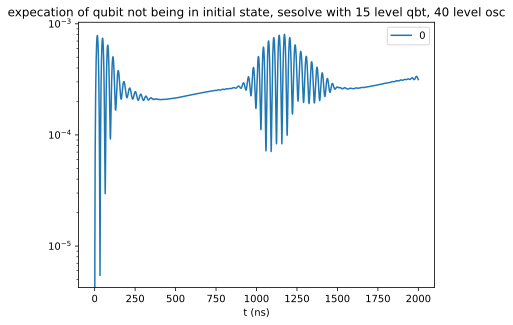

In [13]:
with open('../pickles/sesolve_12_large_dim_leakage_list_2.65_g0.13_a0.003_go_back.pkl', 'rb') as file:
    lists = pickle.load(file)
    
for ql,pop_list in enumerate([lists[0]]): 
    plt.plot(tlist,pop_list,label = f"{ql}")  
plt.yscale('log')
plt.legend()
plt.title('expecation of qubit not being in initial state, sesolve with 15 level qbt, 40 level osc')
plt.xlabel('t (ns)')